# Fish Presence in MOT Vision Set
**[This is made with claude]**

Plots showing fish presence, track activity, spatial distribution, and cross-sequence stats across all MOT sequences.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from pathlib import Path

In [2]:
MOT_ROOT = Path(".")  # run from the MOT/ directory, or set absolute path
GT_COLS = ["frame_id", "track_id", "x", "y", "w", "h", "not_ignored", "class_id", "visibility"]
CLASS_NAMES = {1: "fish", 2: "net"}
CLASS_COLORS = {1: "steelblue", 2: "tomato"}

sequences = sorted([p for p in MOT_ROOT.iterdir() if p.is_dir()])
print(f"Found {len(sequences)} sequences:")
for s in sequences:
    print(" ", s.name)

Found 7 sequences:
  2024-08-20_14-31-29
  2024-08-20_17-02-00
  2024-08-20_17-14-36
  2024-08-20_17-34-52
  2024-08-20_17-39-32
  2024-08-20_17-40-54
  2024-08-20_17-55-40


In [3]:
def load_gt(seq_path: Path) -> pd.DataFrame:
    """Load gt/gt.txt, mapping frame_ids to sequential frame numbers via image filenames.
    Image filename stems equal the frame_id in gt.txt, so we sort the images to build
    the true 1-indexed frame map — fish may not appear in frame 1.
    """
    img_dir = seq_path / "frames" / seq_path.name
    img_files = sorted(img_dir.glob("*.jpg"))
    frame_id_to_num = {int(f.stem): i + 1 for i, f in enumerate(img_files)}

    gt_file = seq_path / "gt" / "gt.txt"
    df = pd.read_csv(gt_file, header=None, names=GT_COLS)
    df["sequence"] = seq_path.name
    df["total_frames"] = len(img_files)
    df["frame_norm"] = df["frame_id"].map(frame_id_to_num)
    df["cx"] = df["x"] + df["w"] / 2
    df["cy"] = df["y"] + df["h"] / 2
    return df

all_dfs = [load_gt(s) for s in sequences]
all_data = pd.concat(all_dfs, ignore_index=True)
fish_data = all_data[all_data["class_id"] == 1].copy()

print(f"Total annotations:      {len(all_data):,}")
print(f"Fish annotations:       {len(fish_data):,}")
print(f"Net annotations:        {len(all_data[all_data['class_id']==2]):,}")

Total annotations:      12,515
Fish annotations:       12,515
Net annotations:        0


## 1  Dataset summary

In [4]:
rows = []
for df in all_dfs:
    seq = df["sequence"].iloc[0]
    n_frames = df["frame_norm"].nunique() if not df.empty else 0
    # Count image files to get total frame count (including empty frames)
    total_frames = int(df["total_frames"].iloc[0])
    fish = df[df["class_id"] == 1]
    n_tracks = fish["track_id"].nunique()
    n_annot = len(fish)
    frames_w_fish = fish["frame_norm"].nunique()
    rows.append({
        "Sequence": seq,
        "Total frames": total_frames,
        "Frames w/ fish": frames_w_fish,
        "Fish annots": n_annot,
        "Unique fish tracks": n_tracks,
        "Avg fish/frame": round(n_annot / max(frames_w_fish, 1), 2),
    })

summary = pd.DataFrame(rows)
display(summary)

,Sequence,Total frames,Frames w/ fish,Fish annots,Unique fish tracks,Avg fish/frame
0,2024-08-20_14-31-29,1500,386,4967,53,12.87
1,2024-08-20_17-02-00,1212,277,1104,22,3.99
2,2024-08-20_17-14-36,834,481,899,30,1.87
3,2024-08-20_17-34-52,644,418,1783,63,4.27
4,2024-08-20_17-39-32,625,333,500,24,1.50
5,2024-08-20_17-40-54,1018,468,1595,60,3.41
6,2024-08-20_17-55-40,796,370,1667,65,4.51


## 2  Fish count per frame — per sequence

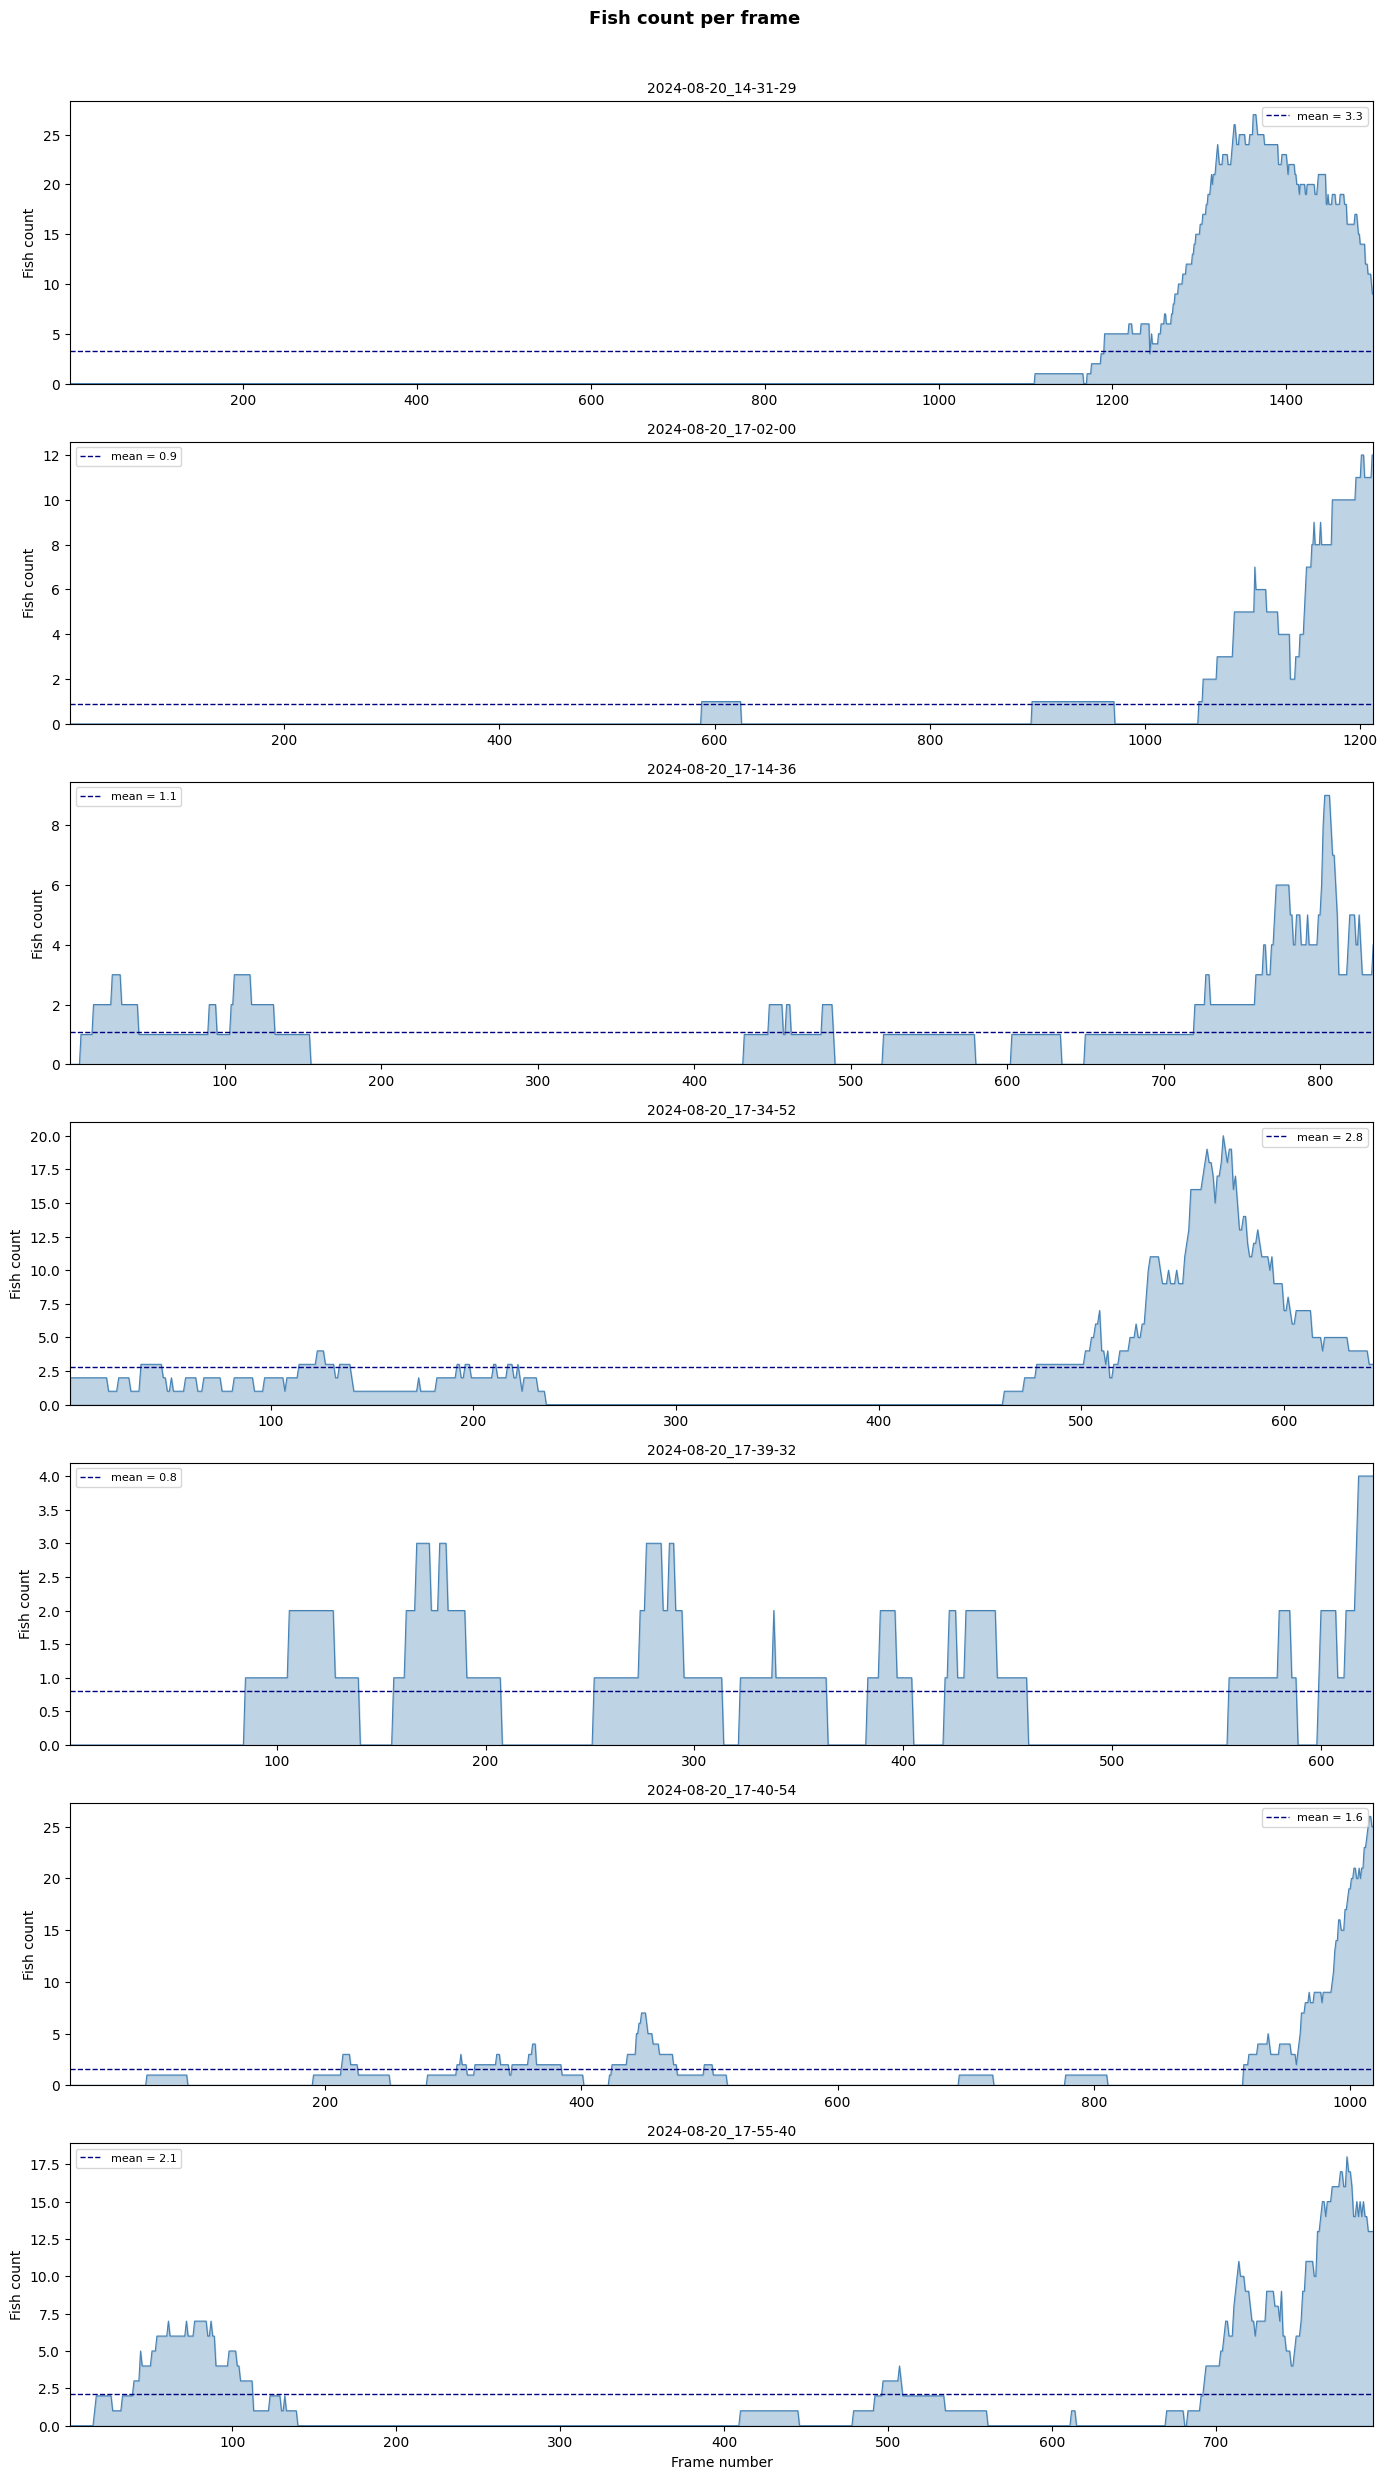

In [5]:
fig, axes = plt.subplots(len(all_dfs), 1, figsize=(14, 3.5 * len(all_dfs)), sharex=False)
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1]

    # Count fish per frame (including zeros for frames with no fish)
    total_frames = int(df["total_frames"].iloc[0])
    all_frames = pd.Series(range(1, total_frames + 1), name="frame_norm")
    fish_per_frame = fish.groupby("frame_norm").size().reindex(all_frames, fill_value=0)

    ax.fill_between(fish_per_frame.index, fish_per_frame.values, alpha=0.35, color="steelblue")
    ax.plot(fish_per_frame.index, fish_per_frame.values, lw=0.8, color="steelblue")
    ax.axhline(fish_per_frame.mean(), color="navy", lw=1, ls="--", label=f"mean = {fish_per_frame.mean():.1f}")
    ax.set_ylabel("Fish count")
    ax.set_title(seq, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(1, total_frames)
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Frame number")
fig.suptitle("Fish count per frame", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fish_count_per_frame.png", dpi=150, bbox_inches="tight")
plt.show()

## 3  Fish presence heatmap (frame × sequence)

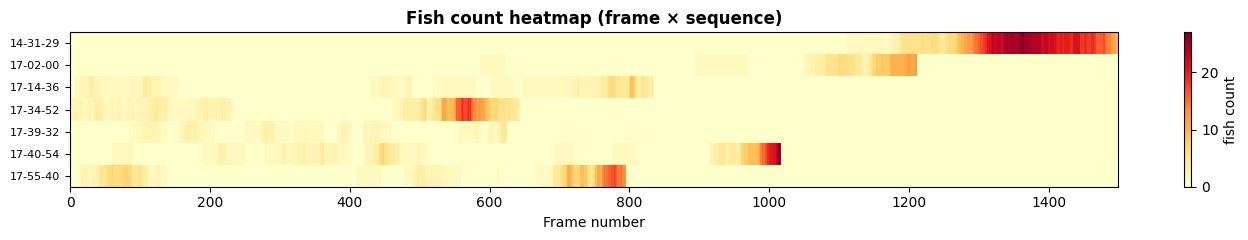

In [6]:
max_frame = max(int(df["total_frames"].iloc[0]) for df in all_dfs)

heatmap = np.zeros((len(all_dfs), max_frame))
seq_labels = []

for i, df in enumerate(all_dfs):
    seq = df["sequence"].iloc[0]
    seq_labels.append(seq)
    fish = df[df["class_id"] == 1]
    for frame, count in fish.groupby("frame_norm").size().items():
        if frame - 1 < max_frame:
            heatmap[i, frame - 1] = count

fig, ax = plt.subplots(figsize=(14, 2.5))
im = ax.imshow(heatmap, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_yticks(range(len(seq_labels)))
ax.set_yticklabels([s[-8:] for s in seq_labels], fontsize=8)  # last 8 chars = time portion
ax.set_xlabel("Frame number")
ax.set_title("Fish count heatmap (frame × sequence)", fontweight="bold")
plt.colorbar(im, ax=ax, label="fish count")
plt.tight_layout()
plt.savefig("fish_presence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4  Track activity timelines (swim lanes)

/tmp/ipykernel_7729/647821654.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(track_ids))
/tmp/ipykernel_7729/647821654.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(track_ids))
/tmp/ipykernel_7729/647821654.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(track_ids))
/tmp/ipykernel_7729/647821654.py:10: MatplotlibDeprecationWarning: The get_cmap funct

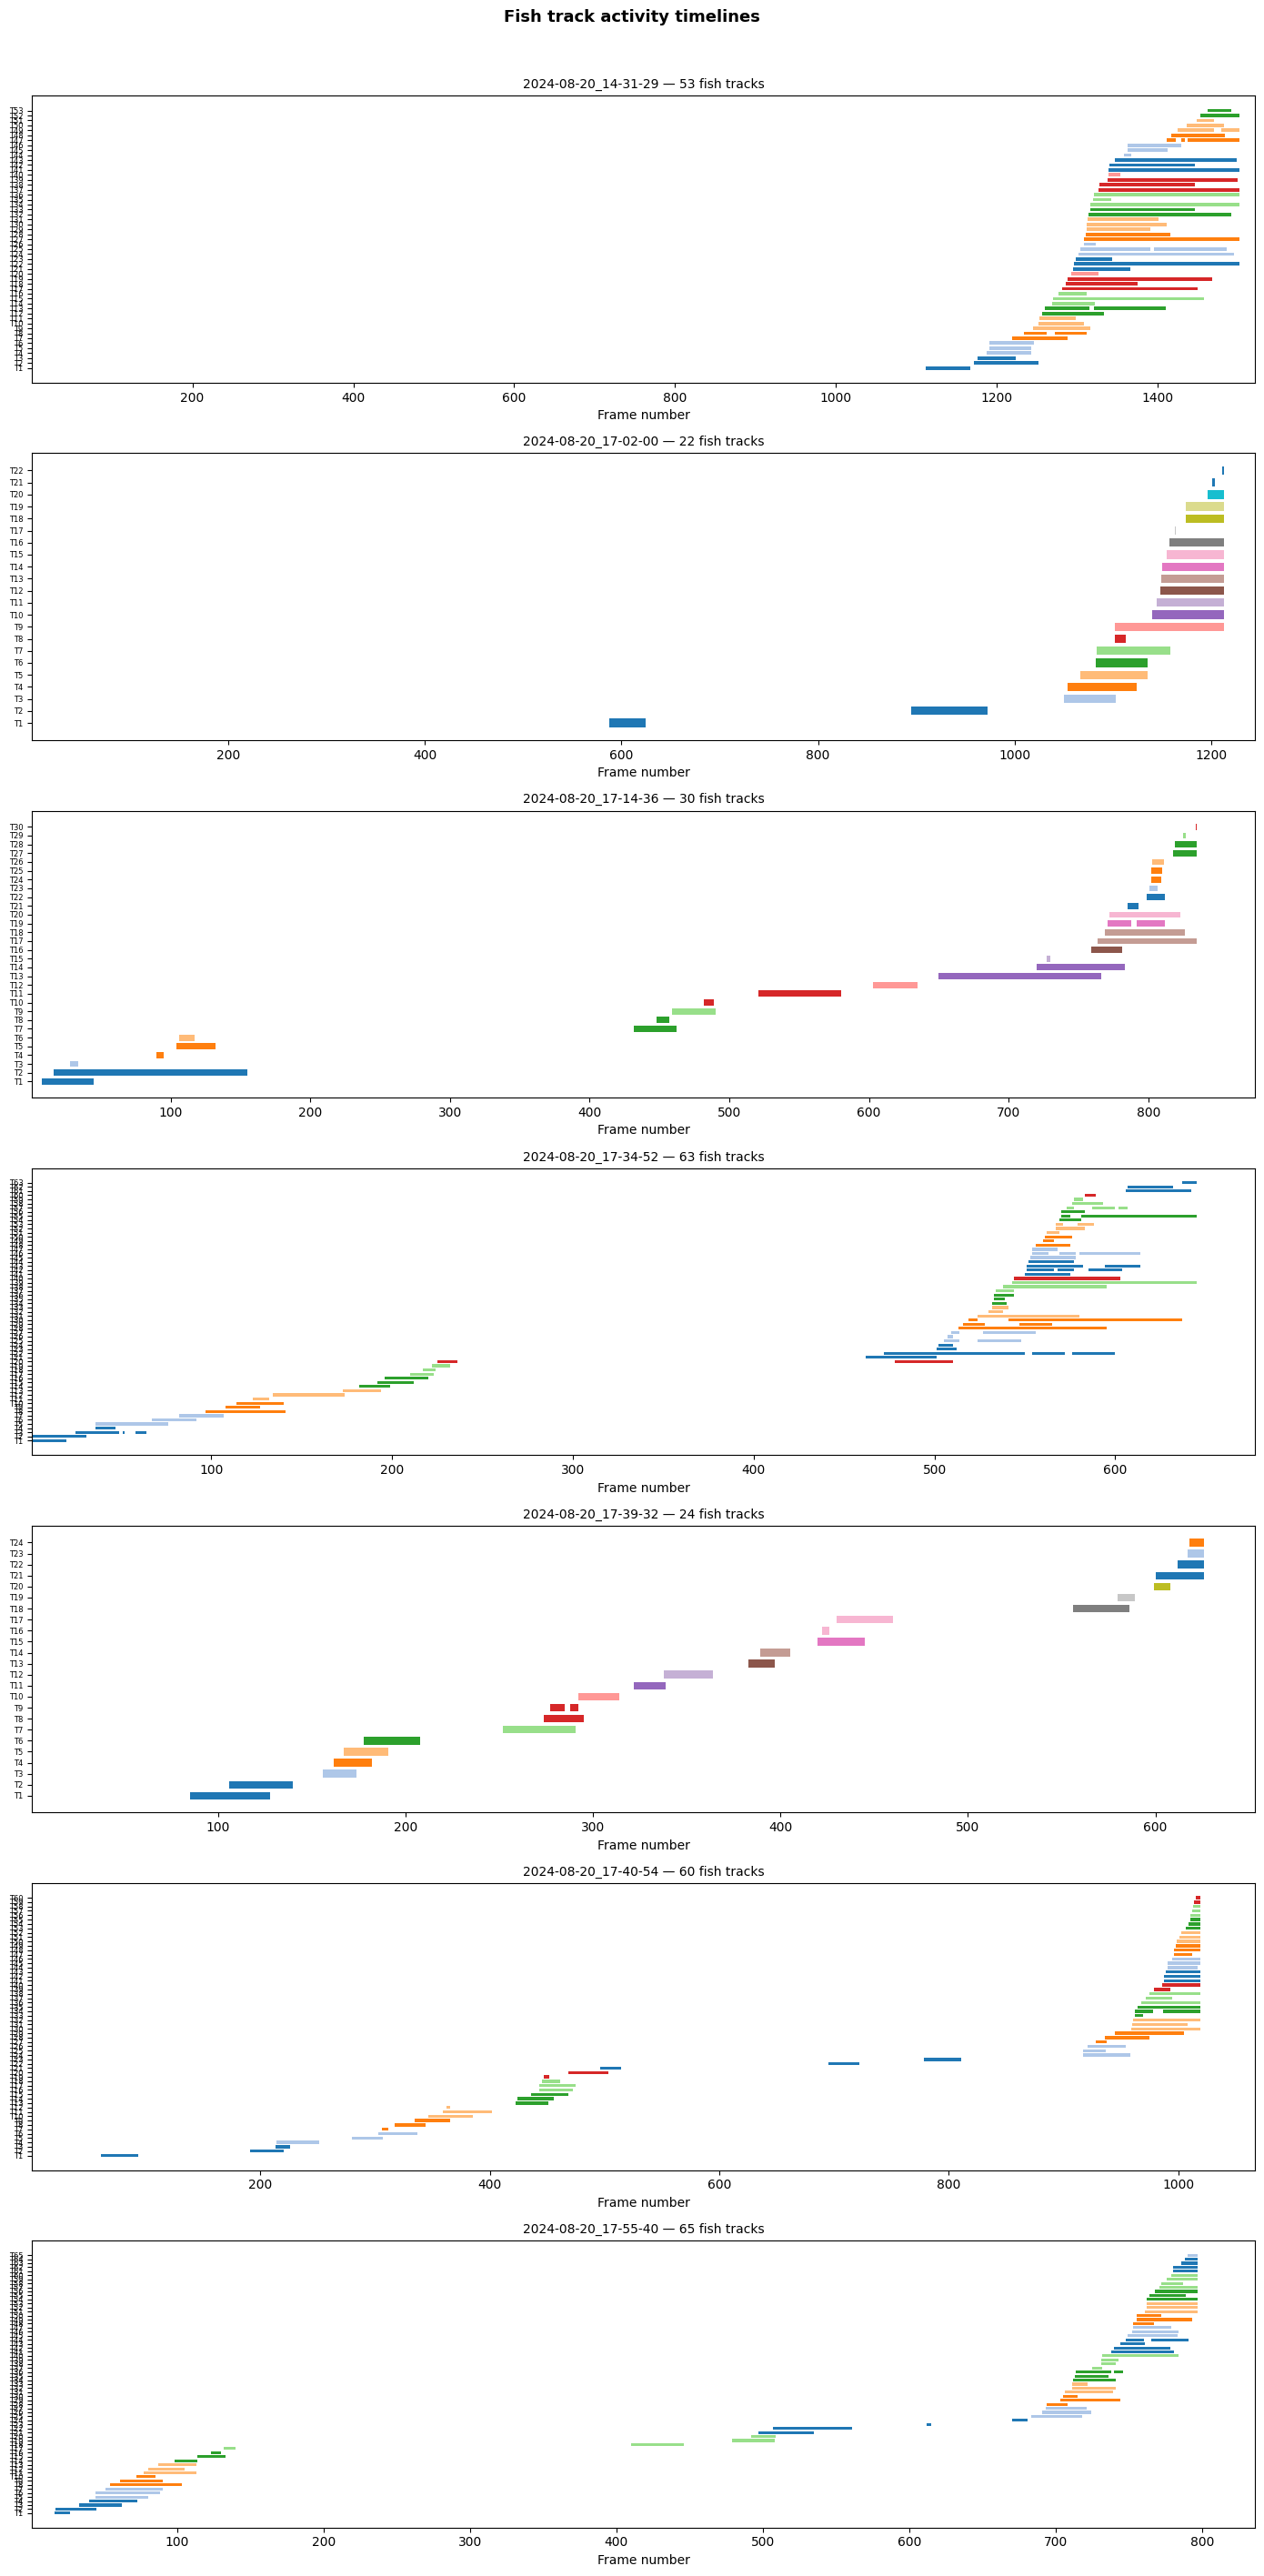

In [7]:
fig, axes = plt.subplots(len(all_dfs), 1, figsize=(14, 4 * len(all_dfs)), sharex=False)
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1].copy()

    track_ids = sorted(fish["track_id"].unique())
    cmap = cm.get_cmap("tab20", len(track_ids))
    tid_to_row = {tid: i for i, tid in enumerate(track_ids)}

    for tid, grp in fish.groupby("track_id"):
        row = tid_to_row[tid]
        frames = sorted(grp["frame_norm"].values)
        # Draw contiguous segments (gaps break the bar)
        seg_start = frames[0]
        prev = frames[0]
        for f in frames[1:]:
            if f > prev + 2:  # gap threshold: >2 frames
                ax.barh(row, prev - seg_start + 1, left=seg_start,
                        height=0.7, color=cmap(tid_to_row[tid] % 20), linewidth=0)
                seg_start = f
            prev = f
        ax.barh(row, prev - seg_start + 1, left=seg_start,
                height=0.7, color=cmap(tid_to_row[tid] % 20), linewidth=0)

    ax.set_yticks(range(len(track_ids)))
    ax.set_yticklabels([f"T{tid}" for tid in track_ids], fontsize=6)
    ax.set_xlabel("Frame number")
    ax.set_title(f"{seq} — {len(track_ids)} fish tracks", fontsize=10)
    ax.set_xlim(left=1)

fig.suptitle("Fish track activity timelines", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fish_track_timelines.png", dpi=150, bbox_inches="tight")
plt.show()

## 5  Track length distribution

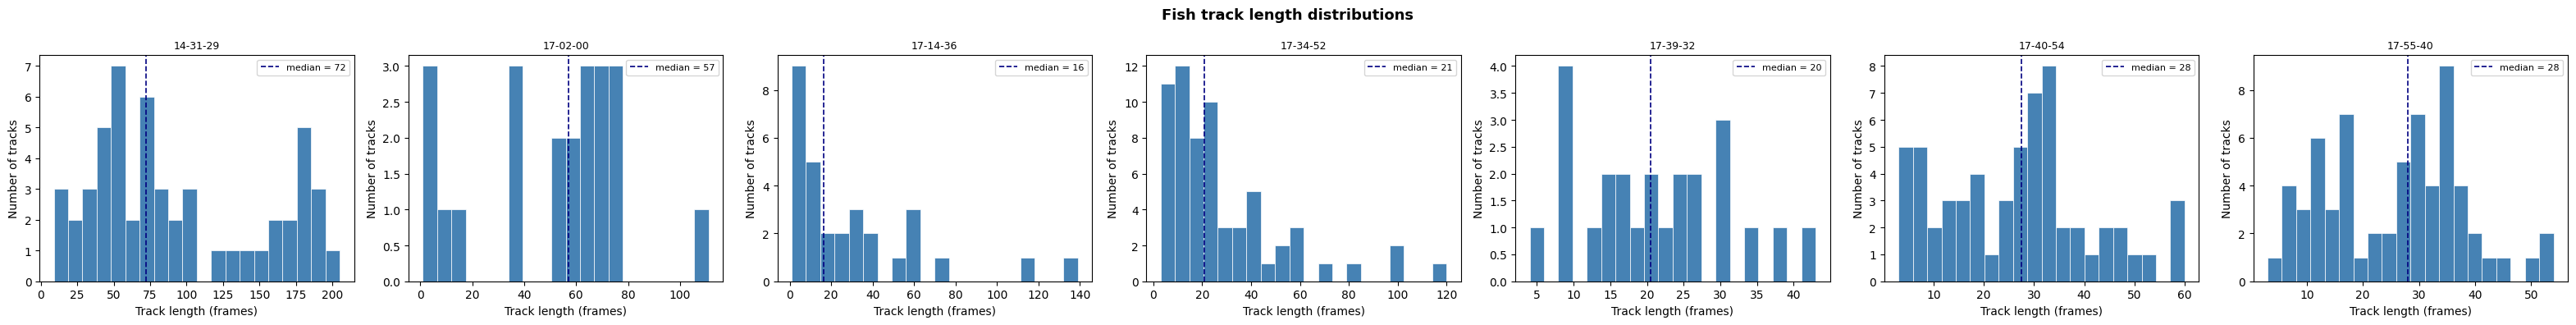

In [8]:
fig, axes = plt.subplots(1, len(all_dfs), figsize=(4.5 * len(all_dfs), 4), sharey=False)
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1]
    track_lengths = fish.groupby("track_id")["frame_norm"].nunique()
    ax.hist(track_lengths, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
    ax.axvline(track_lengths.median(), color="navy", ls="--", lw=1.2,
               label=f"median = {track_lengths.median():.0f}")
    ax.set_xlabel("Track length (frames)")
    ax.set_ylabel("Number of tracks")
    ax.set_title(seq[-8:], fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("Fish track length distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_track_length_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 6  Fish count distribution per frame

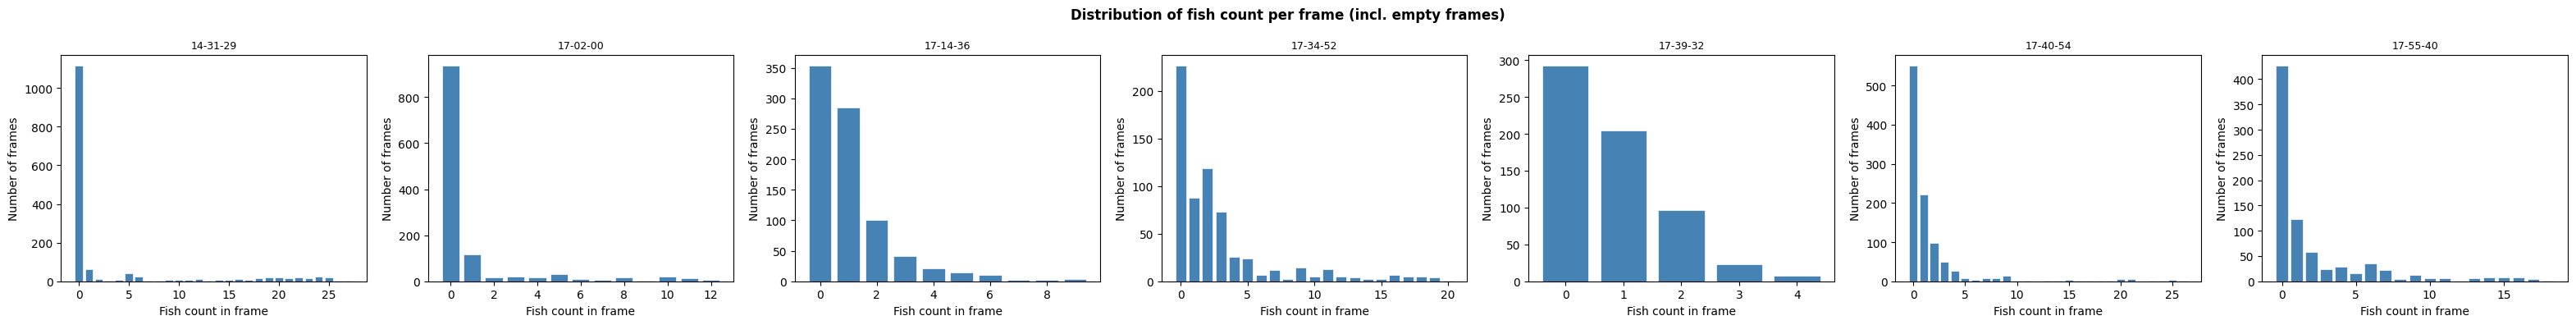

In [9]:
fig, axes = plt.subplots(1, len(all_dfs), figsize=(4.5 * len(all_dfs), 4), sharey=False)
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1]

    total_frames = int(df["total_frames"].iloc[0])
    all_frames = pd.Series(range(1, total_frames + 1), name="frame_norm")
    fish_per_frame = fish.groupby("frame_norm").size().reindex(all_frames, fill_value=0)

    counts = fish_per_frame.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Fish count in frame")
    ax.set_ylabel("Number of frames")
    ax.set_title(seq[-8:], fontsize=9)

fig.suptitle("Distribution of fish count per frame (incl. empty frames)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 7  Spatial distribution of fish bounding box centres

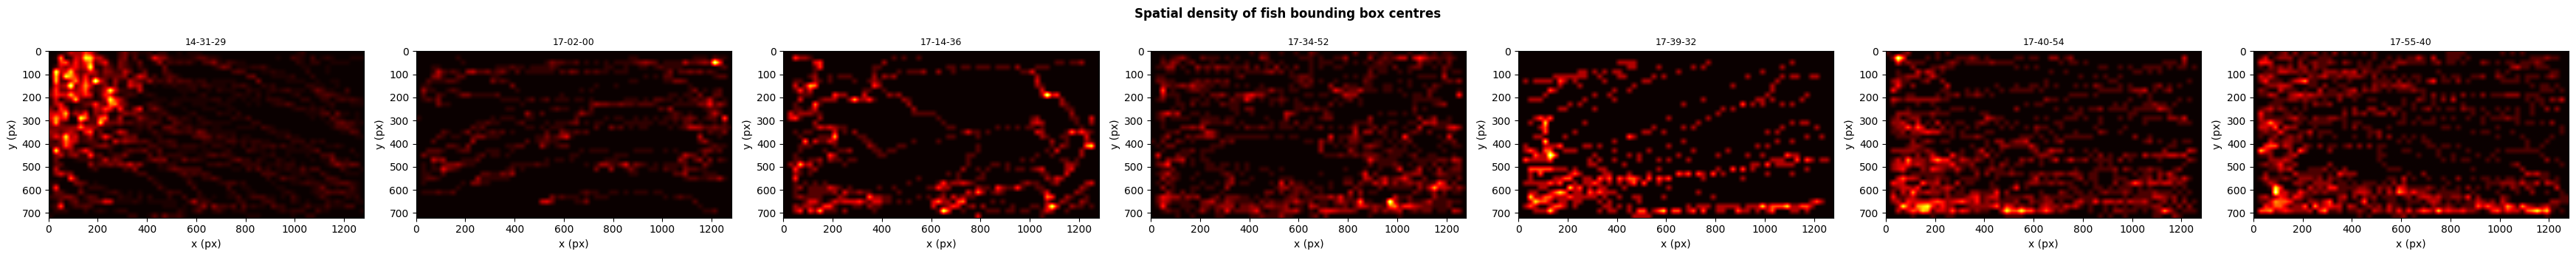

In [10]:
IMG_W, IMG_H = 1280, 720  # adjust if your resolution differs

fig, axes = plt.subplots(1, len(all_dfs), figsize=(5 * len(all_dfs), 3.5))
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1]

    h, xedges, yedges = np.histogram2d(
        fish["cx"], fish["cy"],
        bins=[64, 36],
        range=[[0, IMG_W], [0, IMG_H]]
    )
    ax.imshow(h.T, origin="upper", extent=[0, IMG_W, IMG_H, 0],
              cmap="hot", aspect="auto", interpolation="bilinear")
    ax.set_xlim(0, IMG_W)
    ax.set_ylim(IMG_H, 0)  # image coordinates: y=0 at top
    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")
    ax.set_title(seq[-8:], fontsize=9)

fig.suptitle("Spatial density of fish bounding box centres", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_spatial_density.png", dpi=150, bbox_inches="tight")
plt.show()

## 8  Cross-sequence comparison

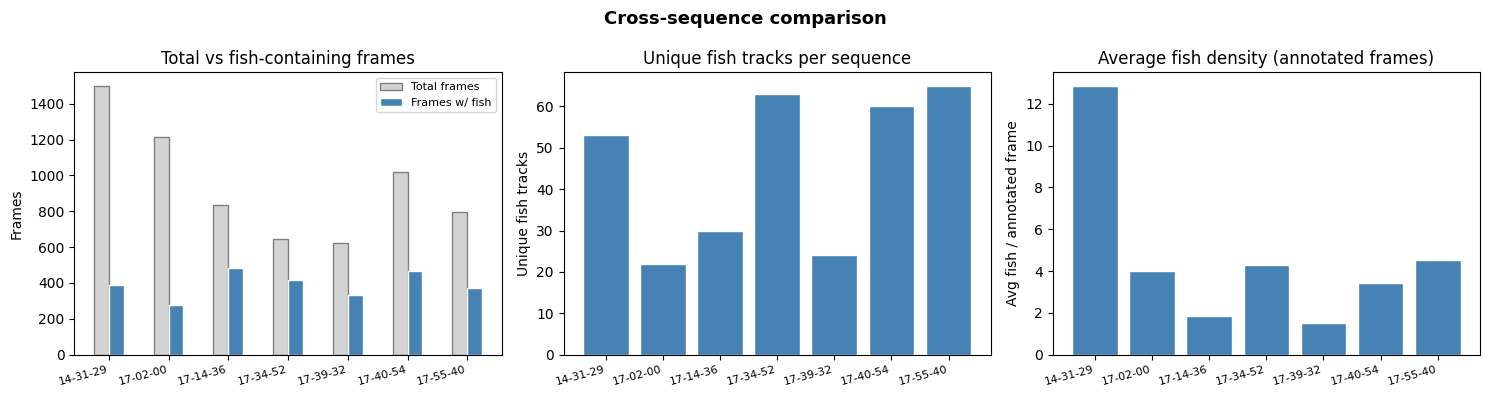

In [11]:
seq_names = [s[-8:] for s in summary["Sequence"]]
x = np.arange(len(seq_names))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total frames vs frames with fish
ax = axes[0]
ax.bar(x - width/2, summary["Total frames"], width, label="Total frames", color="lightgray", edgecolor="gray")
ax.bar(x + width/2, summary["Frames w/ fish"], width, label="Frames w/ fish", color="steelblue", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(seq_names, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Frames")
ax.set_title("Total vs fish-containing frames")
ax.legend(fontsize=8)

# Unique fish tracks
ax = axes[1]
ax.bar(x, summary["Unique fish tracks"], color="steelblue", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(seq_names, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Unique fish tracks")
ax.set_title("Unique fish tracks per sequence")

# Average fish per frame (among frames that have fish)
ax = axes[2]
ax.bar(x, summary["Avg fish/frame"], color="steelblue", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(seq_names, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Avg fish / annotated frame")
ax.set_title("Average fish density (annotated frames)")

fig.suptitle("Cross-sequence comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cross_sequence_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 9  Compute per-step kinematics
For each consecutive pair of detections in a track, compute displacement, speed (px/frame), and heading angle.

In [12]:
def compute_kinematics(df: "pd.DataFrame") -> "pd.DataFrame":
    """Return a dataframe of per-step kinematics for all fish tracks in df."""
    fish = df[df["class_id"] == 1].copy()
    fish = fish.sort_values(["track_id", "frame_norm"])
    fish["dx"] = fish.groupby("track_id")["cx"].diff()
    fish["dy"] = fish.groupby("track_id")["cy"].diff()
    fish["dframe"] = fish.groupby("track_id")["frame_norm"].diff()
    # Keep only truly consecutive steps (no gap > 2 frames)
    fish = fish[fish["dframe"] <= 2].copy()
    fish["speed"] = np.sqrt(fish["dx"] ** 2 + fish["dy"] ** 2) / fish["dframe"]
    fish["angle"] = np.arctan2(fish["dy"], fish["dx"])
    fish["area"] = fish["w"] * fish["h"]
    return fish.dropna(subset=["speed"])

kin_dfs = [compute_kinematics(df) for df in all_dfs]
kin_all = pd.concat(kin_dfs, ignore_index=True)
print(f"Total kinematic steps: {len(kin_all):,}")
print(f"Speed stats (px/frame):  mean={kin_all['speed'].mean():.2f}  median={kin_all['speed'].median():.2f}  p95={kin_all['speed'].quantile(0.95):.2f}")


Total kinematic steps: 12,169
Speed stats (px/frame):  mean=19.36  median=13.80  p95=55.22


## 10  Speed distribution per sequence

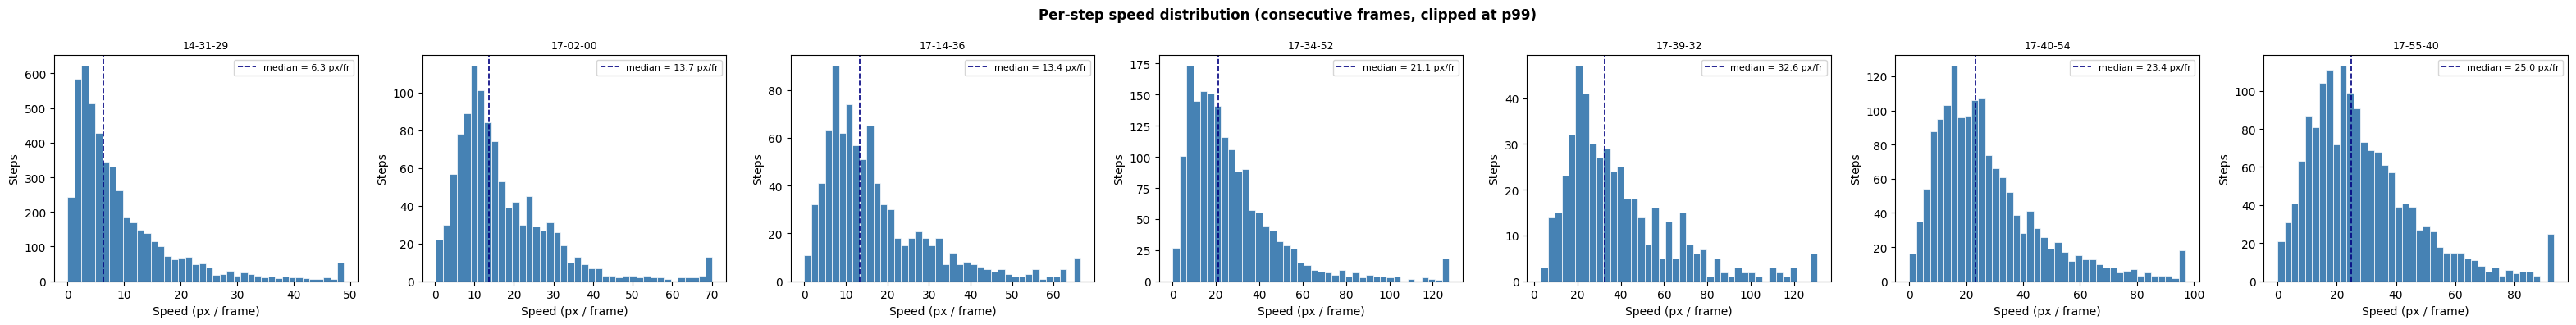

In [13]:
fig, axes = plt.subplots(1, len(kin_dfs), figsize=(4.5 * len(kin_dfs), 4), sharey=False)
if len(kin_dfs) == 1:
    axes = [axes]

for ax, kdf in zip(axes, kin_dfs):
    seq = kdf["sequence"].iloc[0]
    speeds = kdf["speed"].clip(upper=kdf["speed"].quantile(0.99))  # clip extreme outliers for vis
    ax.hist(speeds, bins=40, color="steelblue", edgecolor="white", linewidth=0.5)
    ax.axvline(speeds.median(), color="navy", ls="--", lw=1.2,
               label=f"median = {speeds.median():.1f} px/fr")
    ax.set_xlabel("Speed (px / frame)")
    ax.set_ylabel("Steps")
    ax.set_title(seq[-8:], fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("Per-step speed distribution (consecutive frames, clipped at p99)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_speed_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 11  Movement direction — polar histogram

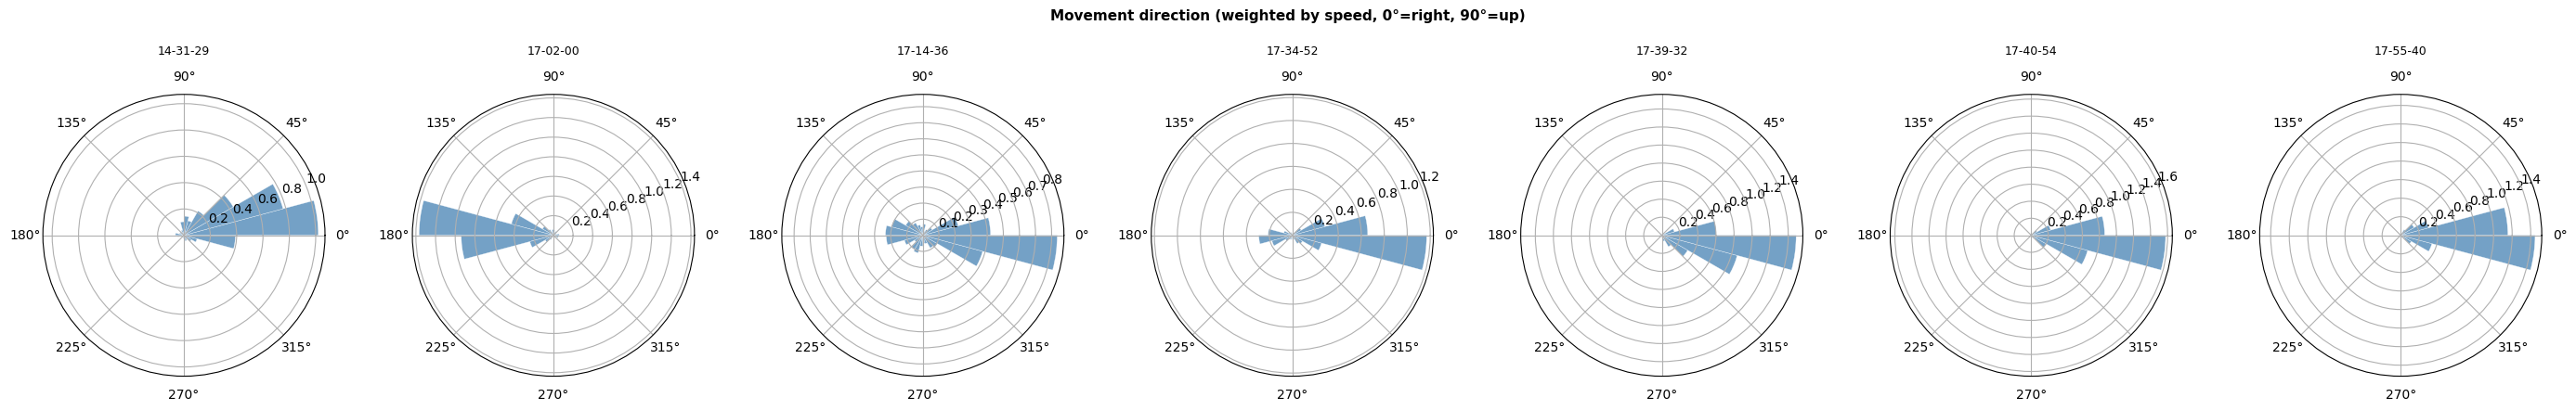

In [14]:
fig, axes = plt.subplots(1, len(kin_dfs), figsize=(4 * len(kin_dfs), 4),
                          subplot_kw={"projection": "polar"})
if len(kin_dfs) == 1:
    axes = [axes]

bins = np.linspace(-np.pi, np.pi, 25)

for ax, kdf in zip(axes, kin_dfs):
    seq = kdf["sequence"].iloc[0]
    # Weight by speed so slow micro-jitter doesn't dominate
    angles = kdf["angle"].values
    weights = kdf["speed"].values
    counts, bin_edges = np.histogram(angles, bins=bins, weights=weights, density=True)
    width = bin_edges[1] - bin_edges[0]
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.bar(centers, counts, width=width, color="steelblue", alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.set_theta_zero_location("E")   # 0° = rightward (+x)
    ax.set_theta_direction(1)         # counter-clockwise (standard math convention; note image y is flipped)
    ax.set_title(seq[-8:], fontsize=9, pad=12)

fig.suptitle("Movement direction (weighted by speed, 0°=right, 90°=up)", fontsize=11, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("fish_movement_direction.png", dpi=150, bbox_inches="tight")
plt.show()


## 12  Individual track trajectories

/tmp/ipykernel_7729/738382067.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(track_ids))


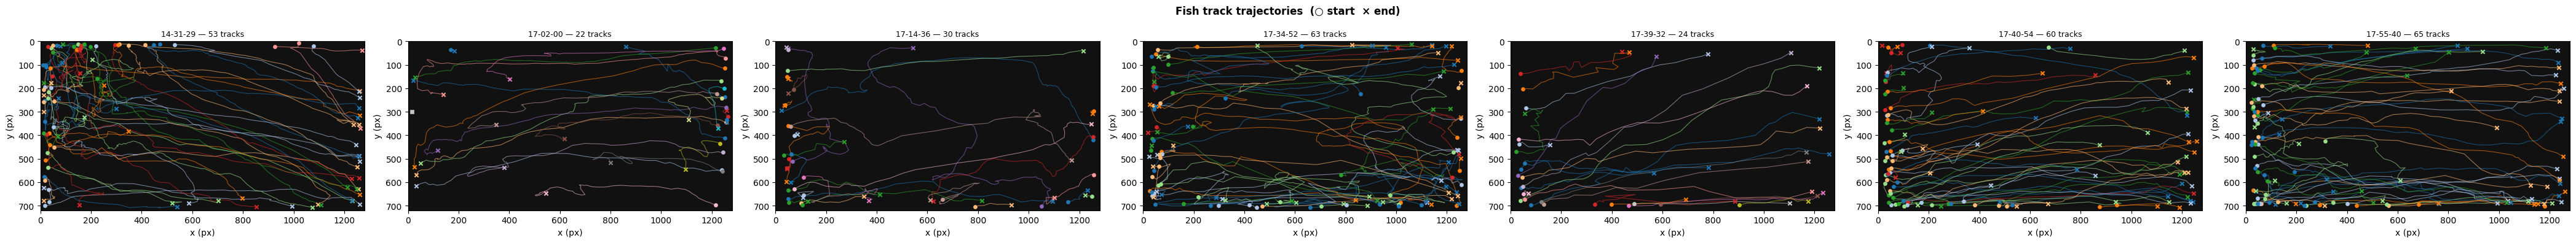

In [15]:
IMG_W, IMG_H = 1280, 720

fig, axes = plt.subplots(1, len(all_dfs), figsize=(6 * len(all_dfs), 4))
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1].copy()
    fish = fish.sort_values(["track_id", "frame_norm"])

    track_ids = fish["track_id"].unique()
    cmap = cm.get_cmap("tab20", len(track_ids))
    tid_color = {tid: cmap(i % 20) for i, tid in enumerate(sorted(track_ids))}

    for tid, grp in fish.groupby("track_id"):
        grp = grp.sort_values("frame_norm")
        ax.plot(grp["cx"], grp["cy"], lw=0.8, alpha=0.6, color=tid_color[tid])
        # Mark start with a dot, end with a cross
        ax.scatter(grp["cx"].iloc[0],  grp["cy"].iloc[0],  s=15, color=tid_color[tid], zorder=3, marker="o")
        ax.scatter(grp["cx"].iloc[-1], grp["cy"].iloc[-1], s=20, color=tid_color[tid], zorder=3, marker="x")

    ax.set_xlim(0, IMG_W)
    ax.set_ylim(IMG_H, 0)   # image coords
    ax.set_facecolor("#111")
    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")
    ax.set_title(f"{seq[-8:]} — {len(track_ids)} tracks", fontsize=9)

fig.suptitle("Fish track trajectories  (○ start  × end)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()


## 13  Entry and exit positions

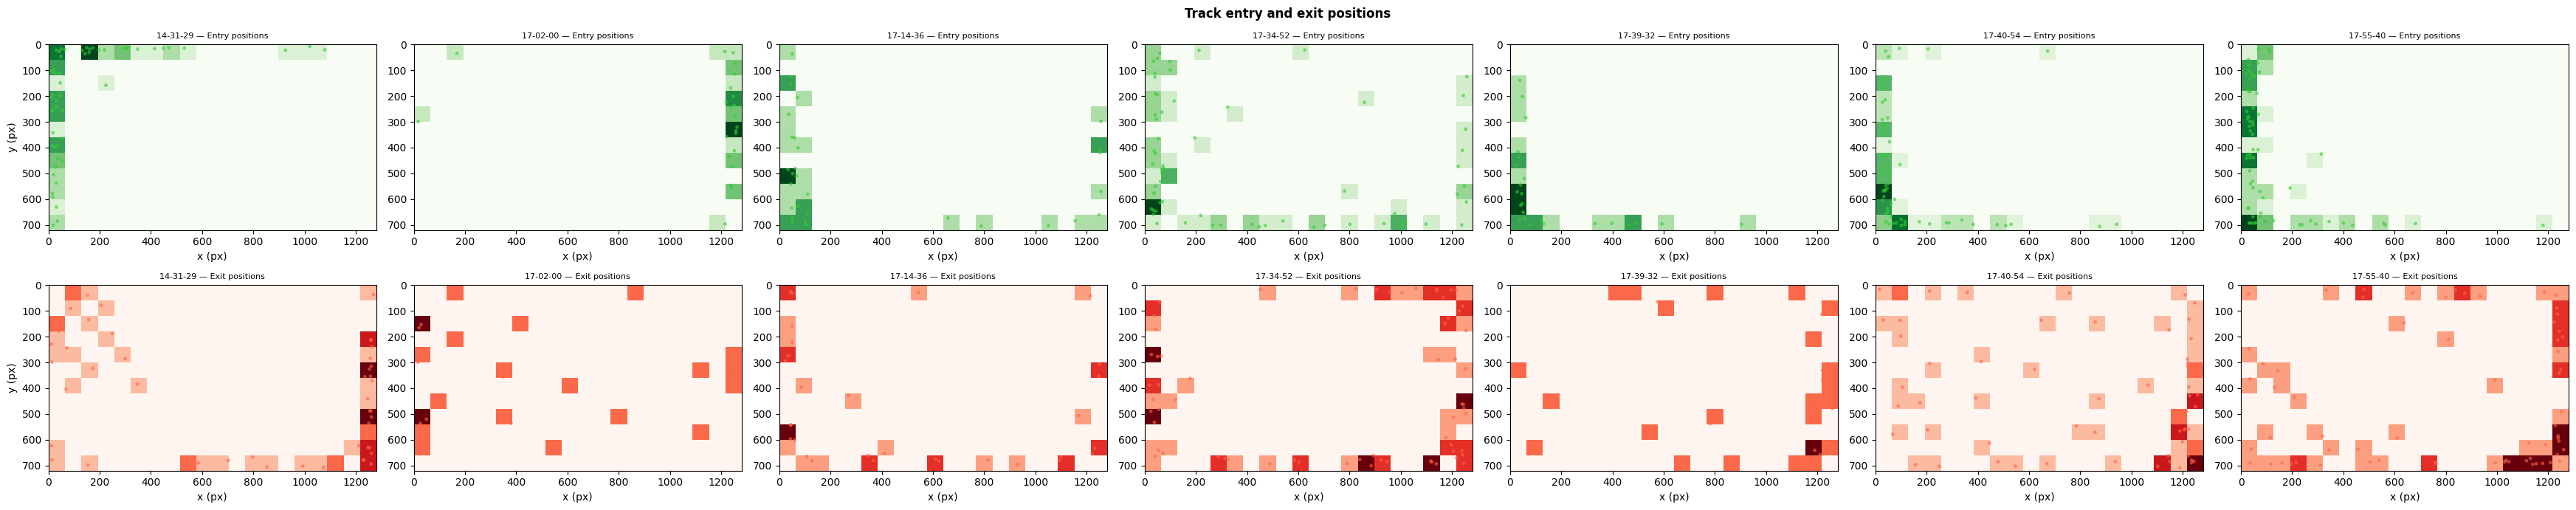

In [16]:
IMG_W, IMG_H = 1280, 720

fig, axes = plt.subplots(2, len(all_dfs), figsize=(5 * len(all_dfs), 7))

for col, df in enumerate(all_dfs):
    seq = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1].sort_values(["track_id", "frame_norm"])

    first = fish.groupby("track_id").first().reset_index()
    last  = fish.groupby("track_id").last().reset_index()

    for row, (pts, label, color) in enumerate([(first, "Entry positions", "limegreen"),
                                               (last,  "Exit positions",  "tomato")]):
        ax = axes[row, col]
        h, xe, ye = np.histogram2d(pts["cx"], pts["cy"], bins=[20, 12],
                                   range=[[0, IMG_W], [0, IMG_H]])
        ax.imshow(h.T, origin="upper", extent=[0, IMG_W, IMG_H, 0],
                  cmap="Greens" if row == 0 else "Reds", aspect="auto")
        ax.scatter(pts["cx"], pts["cy"], s=12, color=color, alpha=0.6, edgecolors="none")
        ax.set_xlim(0, IMG_W)
        ax.set_ylim(IMG_H, 0)
        ax.set_title(f"{seq[-8:]} — {label}", fontsize=8)
        ax.set_xlabel("x (px)")
        if col == 0:
            ax.set_ylabel("y (px)")

fig.suptitle("Track entry and exit positions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_entry_exit.png", dpi=150, bbox_inches="tight")
plt.show()


## 14  Average speed per track

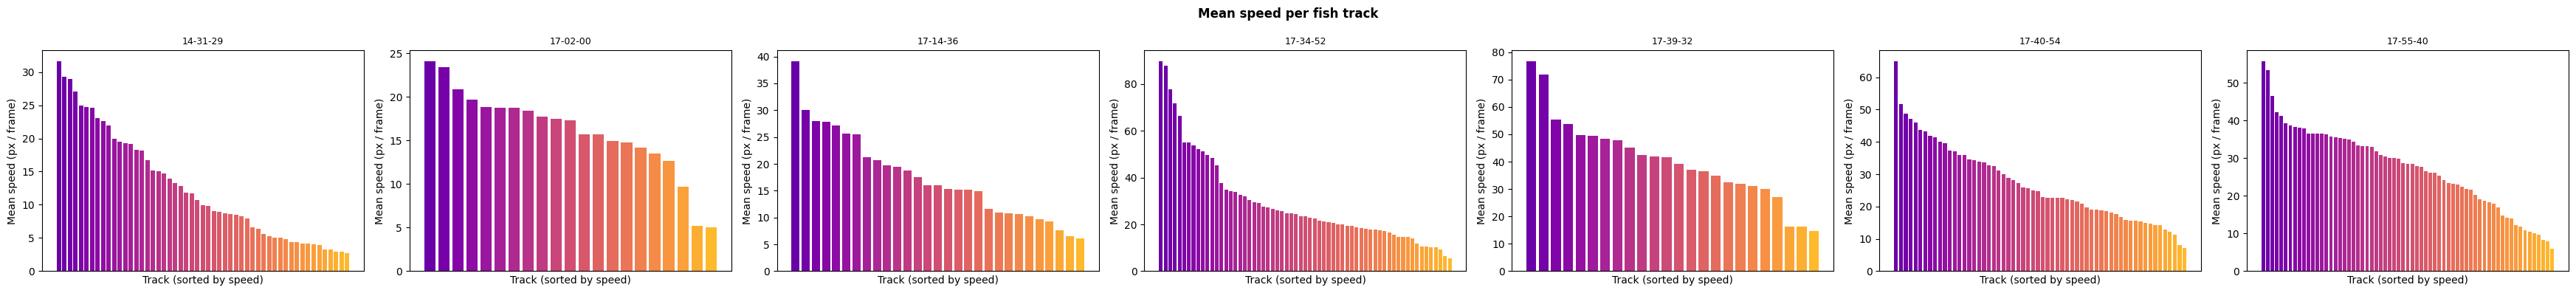

In [17]:
fig, axes = plt.subplots(1, len(kin_dfs), figsize=(5 * len(kin_dfs), 4), sharey=False)
if len(kin_dfs) == 1:
    axes = [axes]

for ax, kdf in zip(axes, kin_dfs):
    seq = kdf["sequence"].iloc[0]
    mean_speed = kdf.groupby("track_id")["speed"].mean().sort_values(ascending=False)
    colors = cm.plasma(np.linspace(0.2, 0.85, len(mean_speed)))
    ax.bar(range(len(mean_speed)), mean_speed.values, color=colors, edgecolor="none")
    ax.set_xlabel("Track (sorted by speed)")
    ax.set_ylabel("Mean speed (px / frame)")
    ax.set_title(seq[-8:], fontsize=9)
    ax.set_xticks([])

fig.suptitle("Mean speed per fish track", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_mean_speed_per_track.png", dpi=150, bbox_inches="tight")
plt.show()


## 15  Speed over track lifetime
Does movement speed change as a track progresses? Normalise each track's frame index to [0, 1].

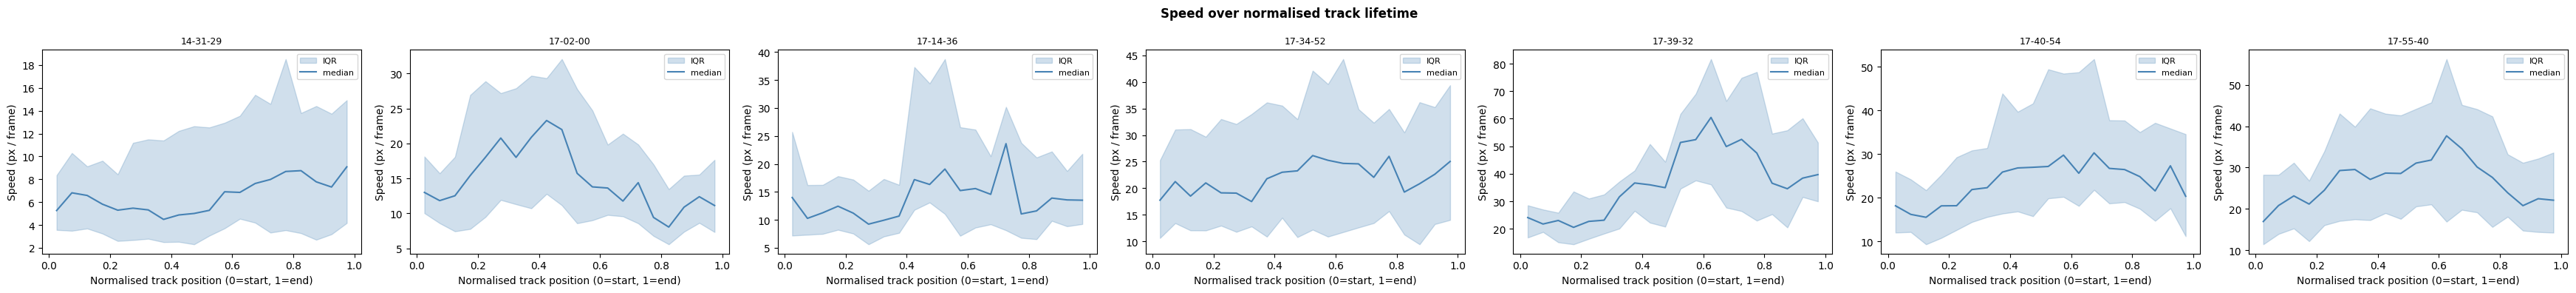

In [18]:
fig, axes = plt.subplots(1, len(kin_dfs), figsize=(5 * len(kin_dfs), 4), sharey=False)
if len(kin_dfs) == 1:
    axes = [axes]

BIN_COUNT = 20

for ax, kdf in zip(axes, kin_dfs):
    seq = kdf["sequence"].iloc[0]
    rows = []
    for tid, grp in kdf.groupby("track_id"):
        grp = grp.sort_values("frame_norm")
        n = len(grp)
        if n < 3:
            continue
        grp = grp.copy()
        grp["t_norm"] = (grp["frame_norm"] - grp["frame_norm"].min()) / max(grp["frame_norm"].max() - grp["frame_norm"].min(), 1)
        rows.append(grp[["t_norm", "speed"]])
    if not rows:
        continue
    combined = pd.concat(rows)
    combined["bin"] = pd.cut(combined["t_norm"], bins=BIN_COUNT, labels=False)
    median_speed = combined.groupby("bin")["speed"].median()
    q25 = combined.groupby("bin")["speed"].quantile(0.25)
    q75 = combined.groupby("bin")["speed"].quantile(0.75)
    xs = (median_speed.index + 0.5) / BIN_COUNT
    ax.fill_between(xs, q25.values, q75.values, alpha=0.25, color="steelblue", label="IQR")
    ax.plot(xs, median_speed.values, color="steelblue", lw=1.5, label="median")
    ax.set_xlabel("Normalised track position (0=start, 1=end)")
    ax.set_ylabel("Speed (px / frame)")
    ax.set_title(seq[-8:], fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("Speed over normalised track lifetime", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_speed_over_lifetime.png", dpi=150, bbox_inches="tight")
plt.show()


## 16  Net displacement vs track length

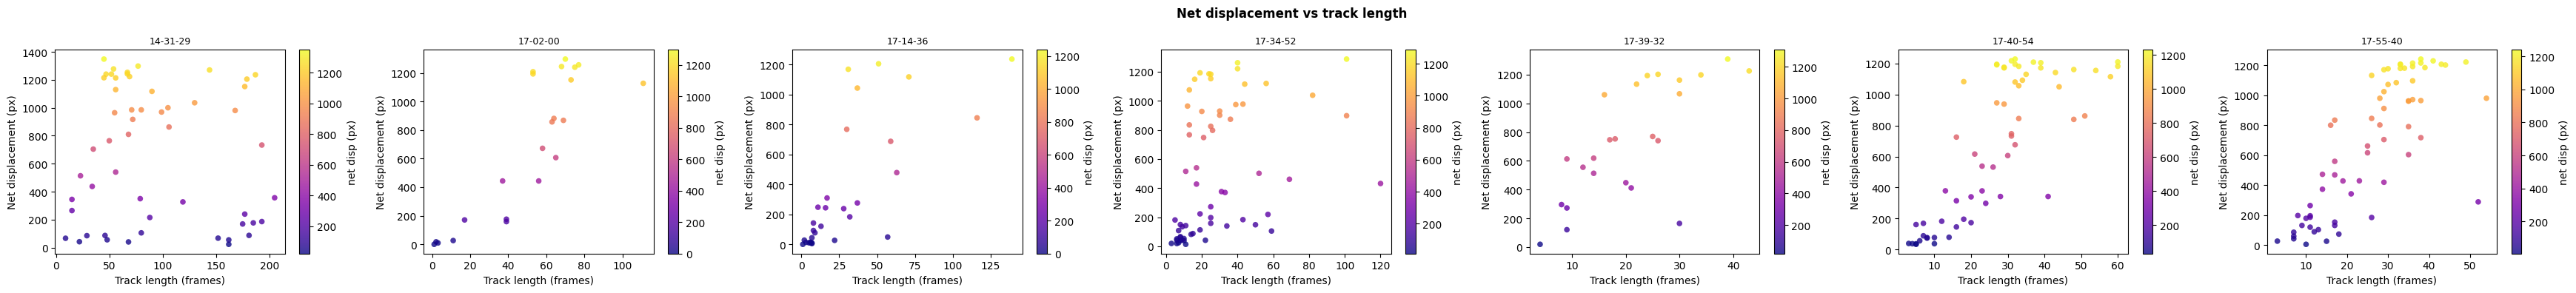

In [19]:
fig, axes = plt.subplots(1, len(all_dfs), figsize=(5 * len(all_dfs), 4))
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1].sort_values(["track_id", "frame_norm"])

    stats = fish.groupby("track_id").agg(
        track_len=("frame_norm", "nunique"),
        cx_first=("cx", "first"),
        cy_first=("cy", "first"),
        cx_last=("cx", "last"),
        cy_last=("cy", "last"),
    ).reset_index()
    stats["net_disp"] = np.sqrt((stats["cx_last"] - stats["cx_first"])**2 +
                                (stats["cy_last"] - stats["cy_first"])**2)

    sc = ax.scatter(stats["track_len"], stats["net_disp"],
                    c=stats["net_disp"], cmap="plasma", s=30, alpha=0.8, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="net disp (px)")
    ax.set_xlabel("Track length (frames)")
    ax.set_ylabel("Net displacement (px)")
    ax.set_title(seq[-8:], fontsize=9)

fig.suptitle("Net displacement vs track length", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_net_displacement.png", dpi=150, bbox_inches="tight")
plt.show()


## 17  Bounding box area over time
Larger area may indicate the fish is closer to the camera.

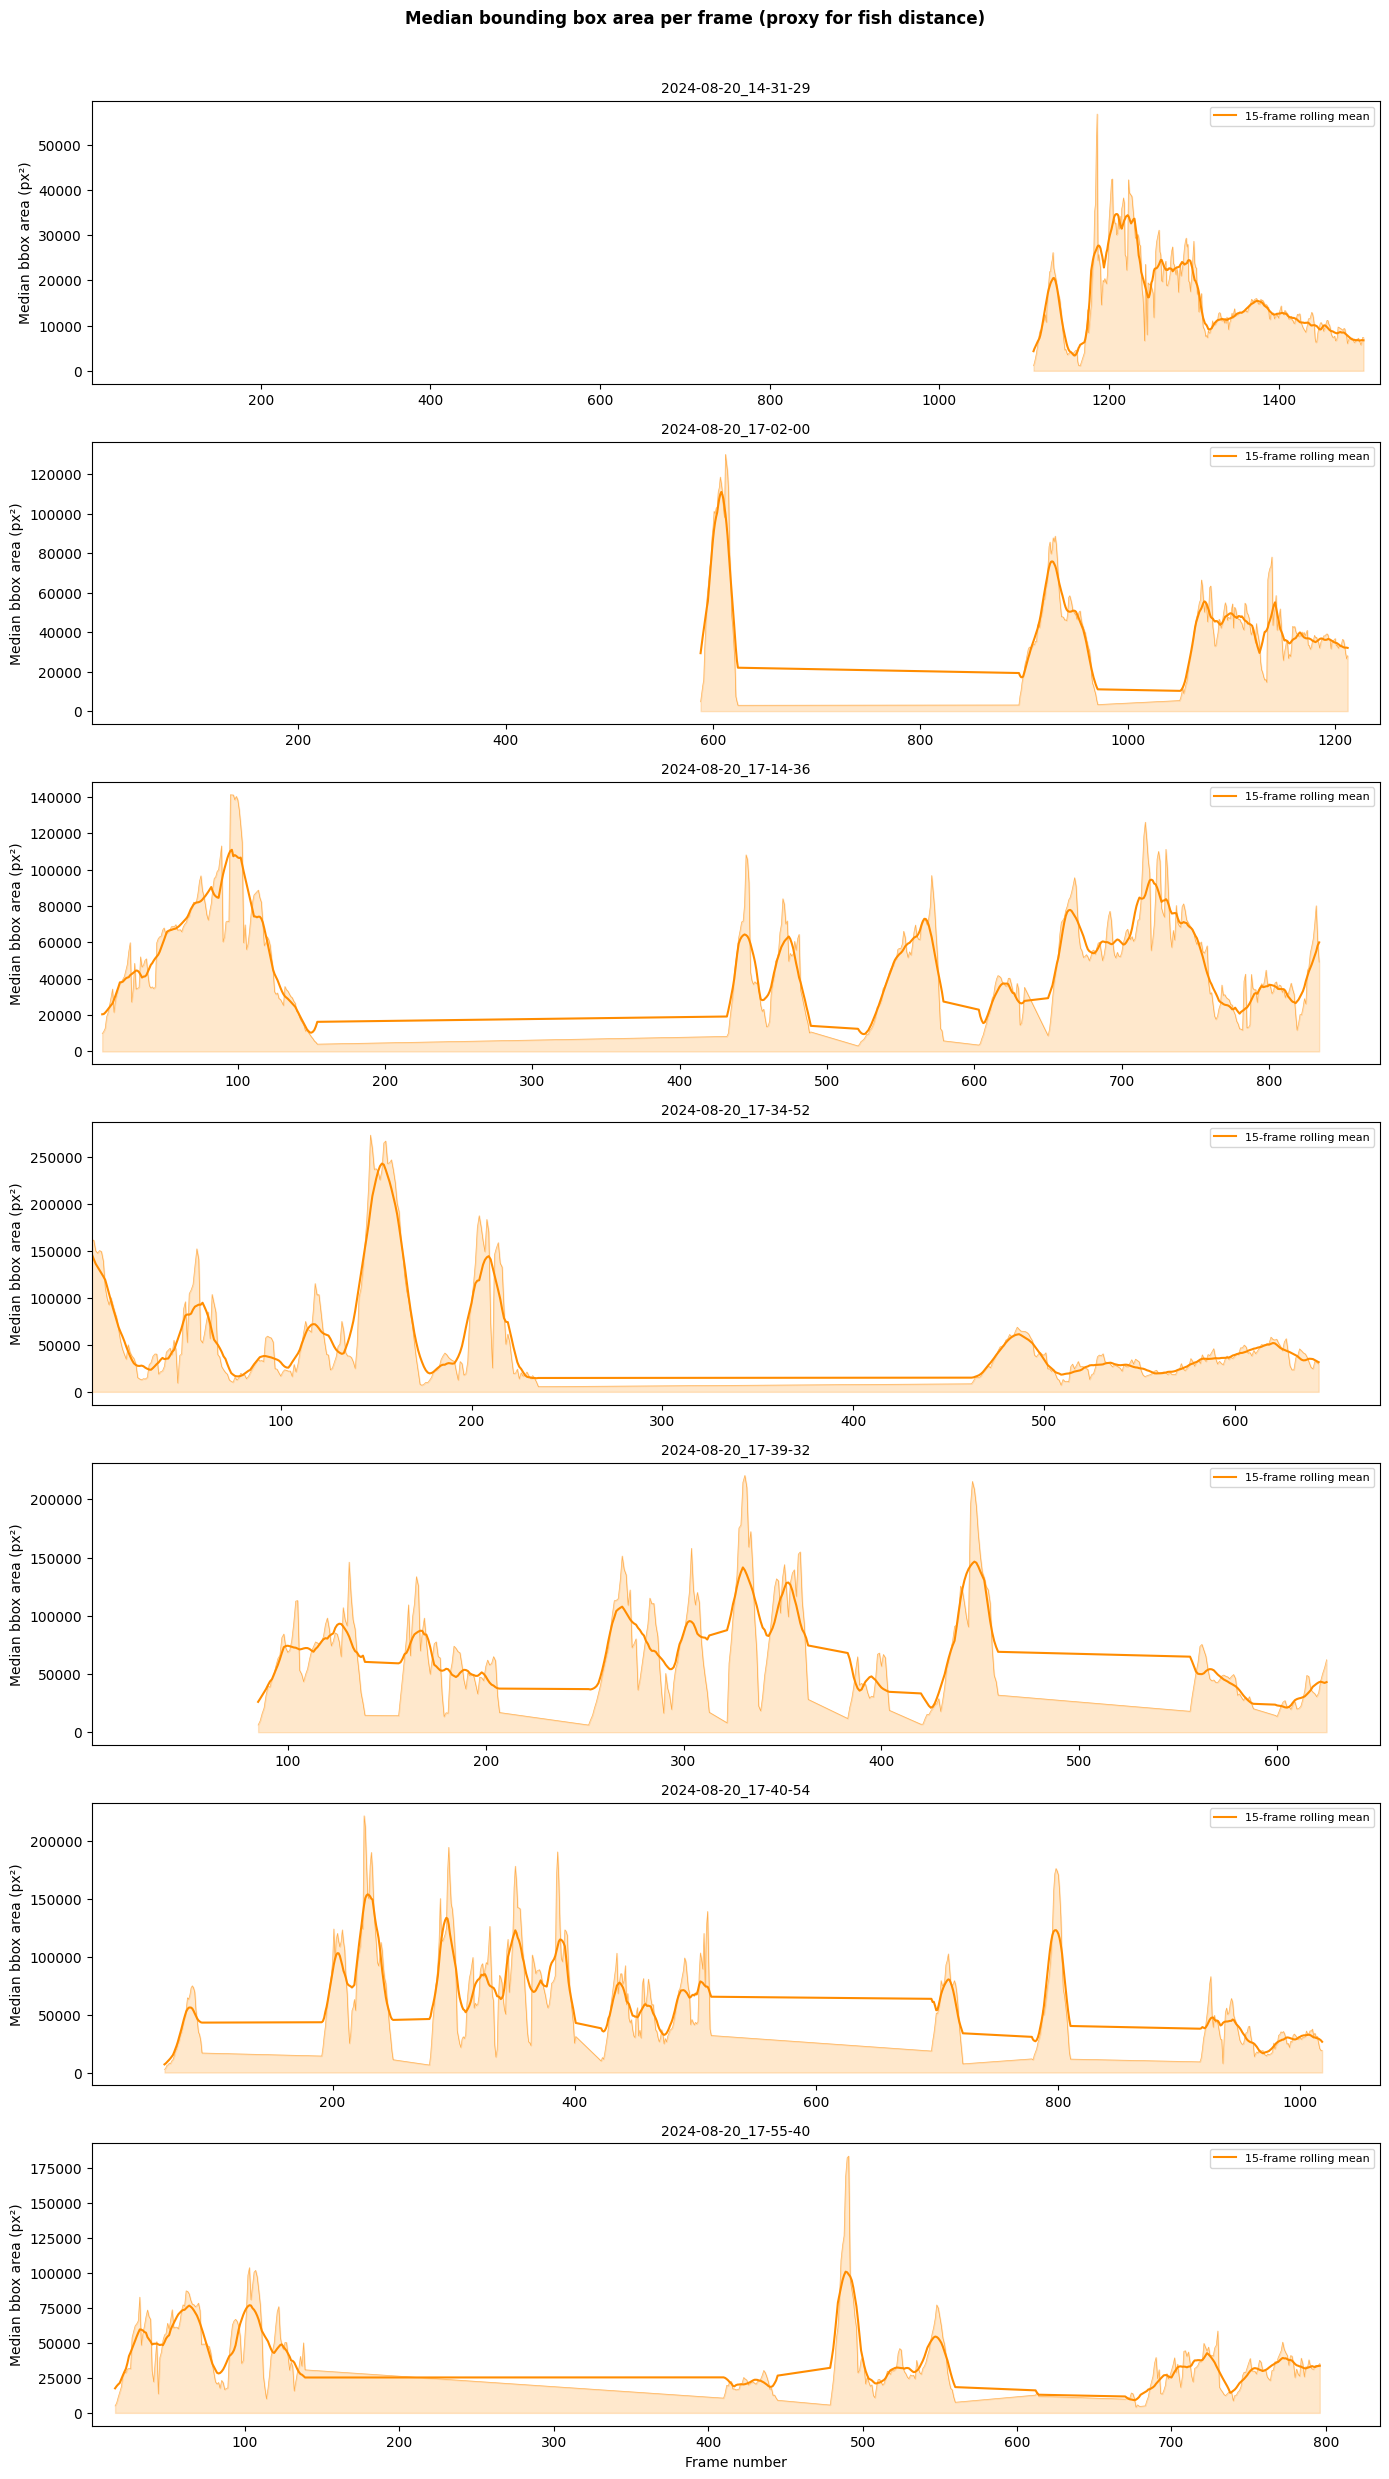

In [20]:
fig, axes = plt.subplots(len(all_dfs), 1, figsize=(14, 3.5 * len(all_dfs)), sharex=False)
if len(all_dfs) == 1:
    axes = [axes]

for ax, df in zip(axes, all_dfs):
    seq = df["sequence"].iloc[0]
    fish = df[df["class_id"] == 1].copy()
    fish["area"] = fish["w"] * fish["h"]

    # Rolling median across all fish per frame
    area_per_frame = fish.groupby("frame_norm")["area"].median()
    smoothed = area_per_frame.rolling(window=15, center=True, min_periods=1).mean()

    ax.fill_between(area_per_frame.index, area_per_frame.values, alpha=0.2, color="darkorange")
    ax.plot(area_per_frame.index, area_per_frame.values, lw=0.5, color="darkorange", alpha=0.6)
    ax.plot(smoothed.index, smoothed.values, lw=1.5, color="darkorange", label="15-frame rolling mean")
    ax.set_ylabel("Median bbox area (px²)")
    ax.set_title(seq, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(left=1)

axes[-1].set_xlabel("Frame number")
fig.suptitle("Median bounding box area per frame (proxy for fish distance)", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fish_bbox_area_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


## 18  Example frame with fish tracks and 30-frame trails

/tmp/ipykernel_7729/99443519.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(present_tracks))


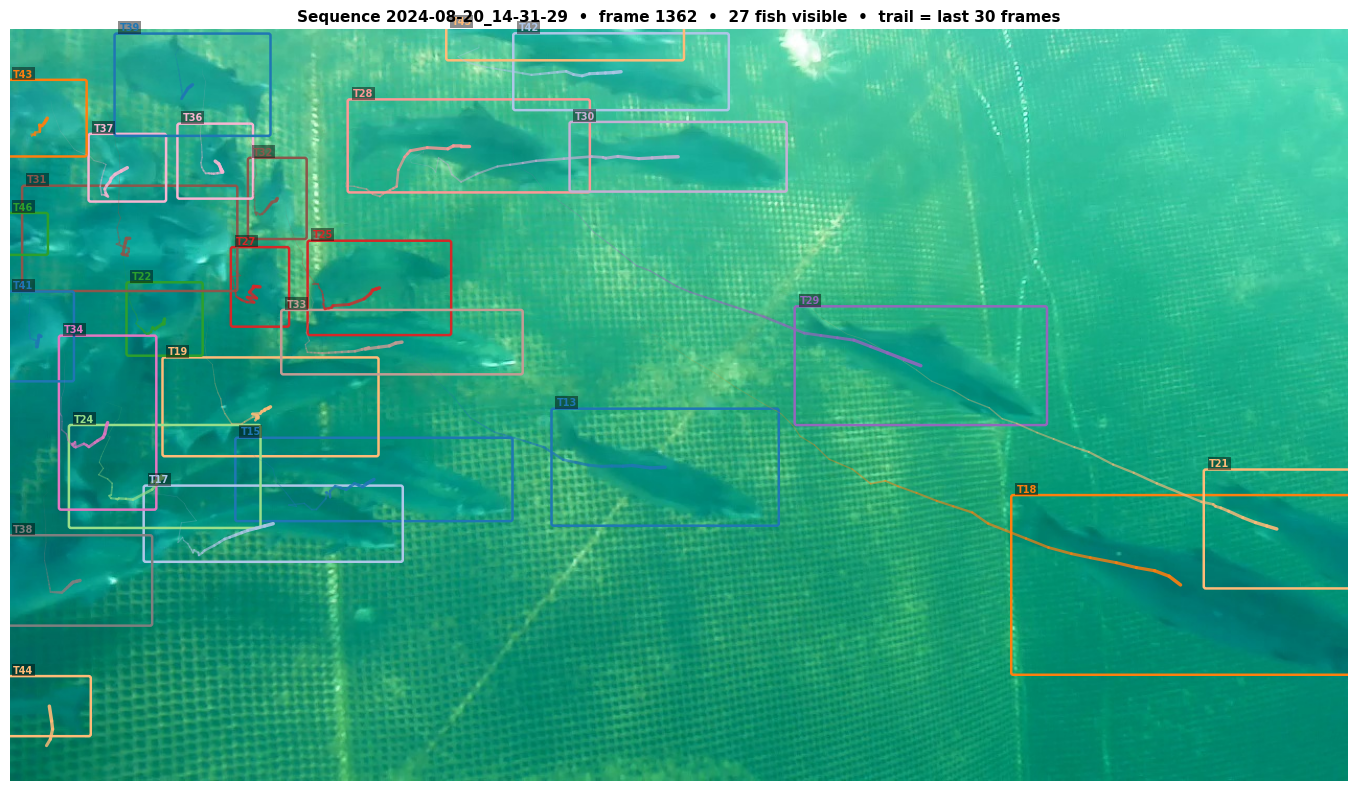

In [21]:
import matplotlib.patches as patches

TRAIL_LEN = 30

# Sequence with highest avg fish/frame
best_seq_idx = int(summary["Avg fish/frame"].idxmax())
df = all_dfs[best_seq_idx]
seq_path = sequences[best_seq_idx]

fish = df[df["class_id"] == 1].copy()

# Build frame_norm → image path mapping
img_dir = seq_path / "frames" / seq_path.name
img_files = sorted(img_dir.glob("*.jpg"))
frame_num_to_path = {i + 1: f for i, f in enumerate(img_files)}

# Pick the frame with the most fish, requiring at least TRAIL_LEN frames of prior history
fish_per_frame = fish.groupby("frame_norm").size()
min_frame = fish["frame_norm"].min() + TRAIL_LEN
chosen_frame = fish_per_frame[fish_per_frame.index >= min_frame].idxmax()

# Tracks visible in the chosen frame
present_tracks = fish[fish["frame_norm"] == chosen_frame]["track_id"].unique()

# History window: last TRAIL_LEN frames for each present track
trail_data = fish[
    fish["track_id"].isin(present_tracks) &
    fish["frame_norm"].between(chosen_frame - TRAIL_LEN, chosen_frame)
]

# Load image
img = plt.imread(str(frame_num_to_path[chosen_frame]))

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)

cmap = cm.get_cmap("tab20", len(present_tracks))
tid_color = {tid: cmap(i % 20) for i, tid in enumerate(sorted(present_tracks))}

# Draw fading trails
for tid, grp in trail_data.groupby("track_id"):
    grp = grp.sort_values("frame_norm")
    xs = grp["cx"].values
    ys = grp["cy"].values
    frames = grp["frame_norm"].values
    color = tid_color[tid]
    for j in range(1, len(xs)):
        age = (chosen_frame - frames[j]) / TRAIL_LEN   # 0 = current, 1 = oldest
        alpha = max(0.05, (1 - age) * 0.9)
        lw = max(0.5, (1 - age) * 2.5)
        ax.plot(xs[j-1:j+1], ys[j-1:j+1],
                color=color, alpha=alpha, lw=lw, solid_capstyle="round")

# Draw bounding boxes and track IDs for the chosen frame
current = fish[fish["frame_norm"] == chosen_frame]
for _, row in current.iterrows():
    tid = row["track_id"]
    color = tid_color[tid]
    rect = patches.FancyBboxPatch(
        (row["x"], row["y"]), row["w"], row["h"],
        linewidth=1.8, edgecolor=color, facecolor="none",
        boxstyle="round,pad=2"
    )
    ax.add_patch(rect)
    ax.text(row["x"] + 3, row["y"] - 5, f"T{int(tid)}",
            color=color, fontsize=7, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.45, pad=1, edgecolor="none"))

ax.set_xlim(0, img.shape[1])
ax.set_ylim(img.shape[0], 0)
ax.set_title(
    f"Sequence {seq_path.name}  •  frame {chosen_frame}  •  "
    f"{len(present_tracks)} fish visible  •  trail = last {TRAIL_LEN} frames",
    fontsize=11, fontweight="bold"
)
ax.axis("off")
plt.tight_layout()
plt.savefig("fish_example_frame_with_tracks.png", dpi=150, bbox_inches="tight")
plt.show()
